#📌 Extracción

In [152]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [153]:
df.shape

(7267, 6)

In [154]:
df.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

#🔧 Transformación

In [155]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


## Exploración inicial del dataset

En esta etapa se realizó una inspección inicial del conjunto de datos para comprender su estructura y las variables disponibles. Se analizaron las columnas, los tipos de datos y la organización de la información.

Se identificó que algunas columnas contienen estructuras anidadas en formato JSON, como las variables relacionadas con información del cliente, servicios contratados y detalles de la cuenta. Estas columnas deberán ser transformadas posteriormente para facilitar su análisis.

Entre las variables más relevantes para el análisis de evasión de clientes se encuentran aquellas relacionadas con características demográficas, servicios contratados, tipo de contrato y métodos de pago, además de la variable `Churn`, que indica si el cliente canceló el servicio.

In [157]:
df['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [158]:
df['Churn'] = df['Churn'].replace('', None)
df['Churn'].unique()

array(['No', 'Yes', None], dtype=object)

In [159]:
df['Churn'].head()

,Churn
0,No
1,No
2,Yes
3,Yes
4,Yes


In [160]:
df_final = pd.concat(
    [df[['customerID','Churn']], customer, phone, internet, account],
    axis=1
)

In [161]:
df_final.isnull().sum()

,0
customerID,0
Churn,224
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [162]:
df_final['Churn'].unique()

array(['No', 'Yes', None], dtype=object)

In [163]:
df_final = df_final.dropna(subset=['Churn'])
df_final.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [164]:
df_final['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [165]:
df_final.duplicated().sum()

np.int64(0)

In [166]:
df_final['InternetService'].unique()

df_final['Contract'].unique()

df_final['PaymentMethod'].unique()

array(['Mailed check', 'Electronic check', 'Credit card (automatic)',
       'Bank transfer (automatic)'], dtype=object)

In [167]:
customer = pd.json_normalize(df['customer'])
phone = pd.json_normalize(df['phone'])
internet = pd.json_normalize(df['internet'])
account = pd.json_normalize(df['account'])

In [168]:
df_final = pd.concat(
    [df[['customerID','Churn']], customer, phone, internet, account],
    axis=1
)

In [169]:
df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [170]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [171]:
df_final['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [172]:
df_final['Cuentas_Diarias'] = df_final['Charges.Monthly'] / 30
df_final[['Charges.Monthly','Cuentas_Diarias']].head()

,Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [173]:
df_final['Cuentas_Diarias'].describe()

,Cuentas_Diarias
count,7267.000000
mean,2.157337
std,1.004319
min,0.608333
25%,1.180833
50%,2.343333
75%,2.995833
max,3.958333


In [174]:
df_final['Churn'] = df_final['Churn'].map({'Yes':1, 'No':0})
df_final['Churn'].value_counts()

,count
Churn,
0.0,5174
1.0,1869


#📊 Carga y análisis

In [175]:
df_final.describe()

,Churn,SeniorCitizen,tenure,Charges.Monthly,Cuentas_Diarias
count,7043.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.265370,0.162653,32.346498,64.720098,2.157337
std,0.441561,0.369074,24.571773,30.129572,1.004319
min,0.000000,0.000000,0.000000,18.250000,0.608333
25%,0.000000,0.000000,9.000000,35.425000,1.180833
50%,0.000000,0.000000,29.000000,70.300000,2.343333
75%,1.000000,0.000000,55.000000,89.875000,2.995833
max,1.000000,1.000000,72.000000,118.750000,3.958333


In [176]:
df_final['tenure'].describe()

,tenure
count,7267.000000
mean,32.346498
std,24.571773
min,0.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


In [177]:
df_final['Charges.Monthly'].describe()

,Charges.Monthly
count,7267.000000
mean,64.720098
std,30.129572
min,18.250000
25%,35.425000
50%,70.300000
75%,89.875000
max,118.750000


In [178]:
df_final['Cuentas_Diarias'].describe()

,Cuentas_Diarias
count,7267.000000
mean,2.157337
std,1.004319
min,0.608333
25%,1.180833
50%,2.343333
75%,2.995833
max,3.958333


In [179]:
df_final['Churn'].value_counts()

,count
Churn,
0.0,5174
1.0,1869


In [180]:
df_final['Contract'].value_counts()

,count
Contract,
Month-to-month,4005
Two year,1743
One year,1519


In [181]:
df_final['InternetService'].value_counts()

,count
InternetService,
Fiber optic,3198
DSL,2488
No,1581


In [182]:
df_final['PaymentMethod'].value_counts()

,count
PaymentMethod,
Electronic check,2445
Mailed check,1665
Bank transfer (automatic),1589
Credit card (automatic),1568


In [183]:
import matplotlib.pyplot as plt
import seaborn as sns

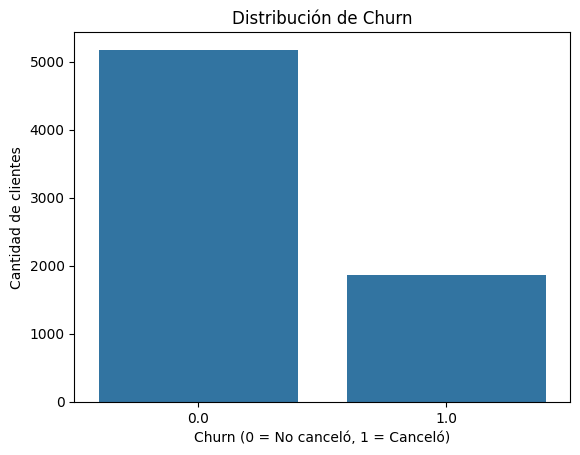

In [184]:
sns.countplot(x='Churn', data=df_final)

plt.title('Distribución de Churn')
plt.xlabel('Churn (0 = No canceló, 1 = Canceló)')
plt.ylabel('Cantidad de clientes')

plt.show()

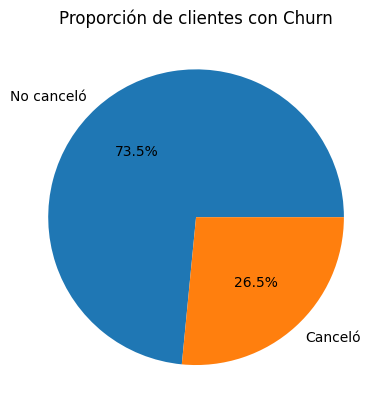

In [185]:
churn_counts = df_final['Churn'].value_counts()

plt.pie(churn_counts,
        labels=['No canceló','Canceló'],
        autopct='%1.1f%%')

plt.title('Proporción de clientes con Churn')

plt.show()

## Distribución de la variable Churn

Se realizaron visualizaciones para analizar la distribución de la variable Churn en el dataset.

Los gráficos muestran la cantidad y proporción de clientes que permanecieron en la empresa y aquellos que cancelaron el servicio. Este análisis permite comprender el nivel de evasión de clientes y sirve como punto de partida para identificar los factores que influyen en la cancelación del servicio.

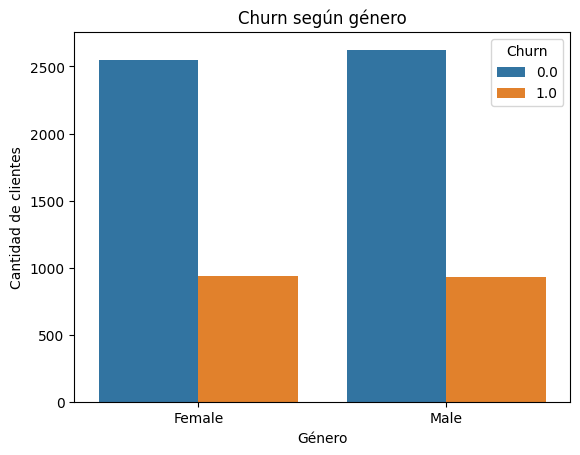

In [186]:
sns.countplot(x='gender', hue='Churn', data=df_final)

plt.title('Churn según género')
plt.xlabel('Género')
plt.ylabel('Cantidad de clientes')

plt.show()

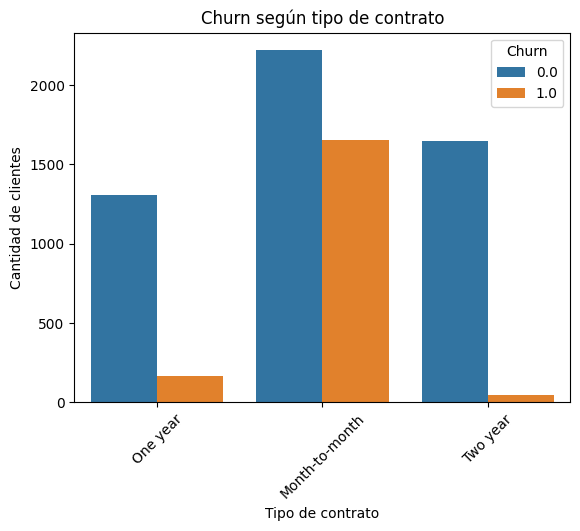

In [187]:
sns.countplot(x='Contract', hue='Churn', data=df_final)

plt.title('Churn según tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad de clientes')

plt.xticks(rotation=45)

plt.show()

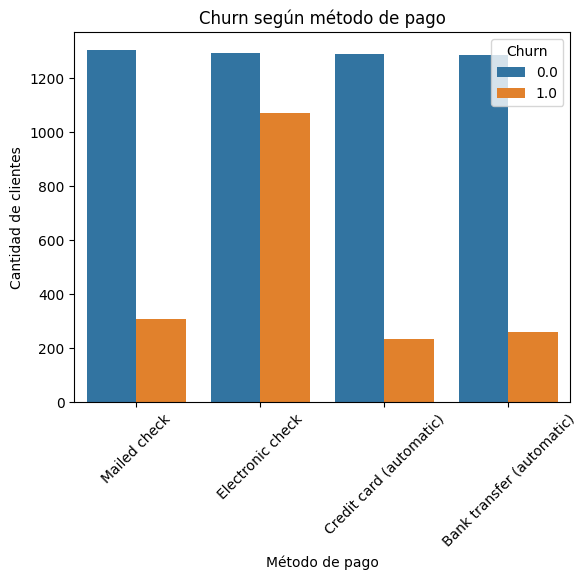

In [188]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df_final)

plt.title('Churn según método de pago')
plt.xlabel('Método de pago')
plt.ylabel('Cantidad de clientes')

plt.xticks(rotation=45)

plt.show()

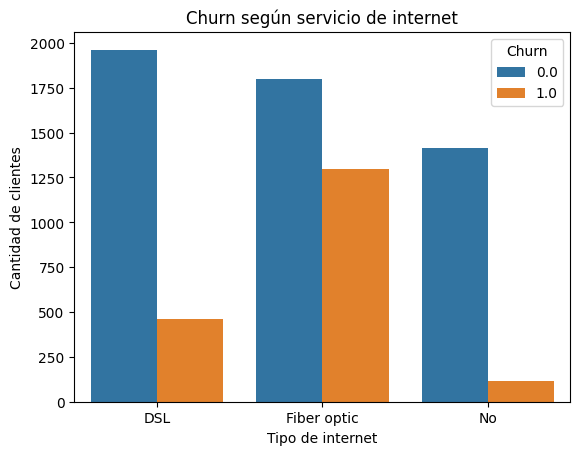

In [189]:
sns.countplot(x='InternetService', hue='Churn', data=df_final)

plt.title('Churn según servicio de internet')
plt.xlabel('Tipo de internet')
plt.ylabel('Cantidad de clientes')

plt.show()

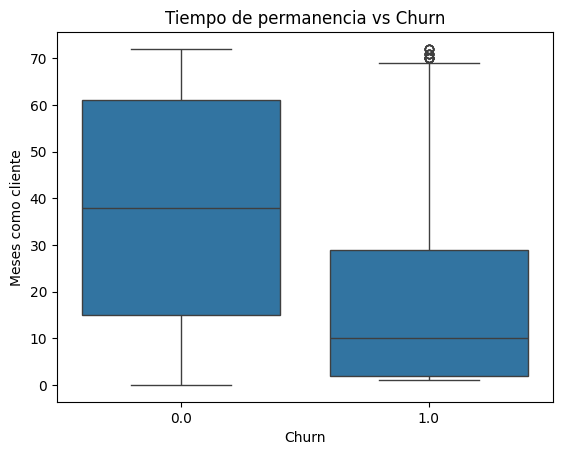

In [190]:
sns.boxplot(x='Churn', y='tenure', data=df_final)

plt.title('Tiempo de permanencia vs Churn')
plt.xlabel('Churn')
plt.ylabel('Meses como cliente')

plt.show()

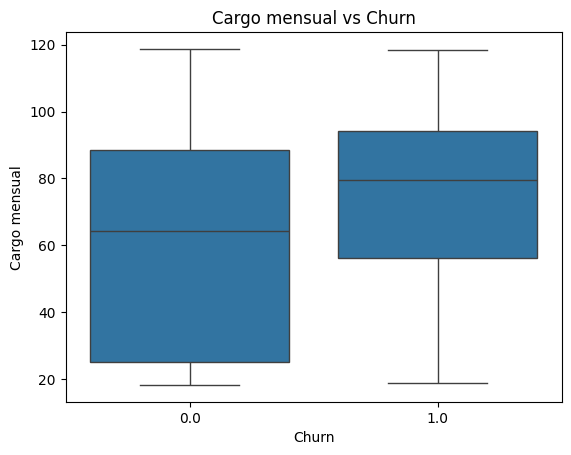

In [191]:
sns.boxplot(x='Churn', y='Charges.Monthly', data=df_final)

plt.title('Cargo mensual vs Churn')
plt.xlabel('Churn')
plt.ylabel('Cargo mensual')

plt.show()

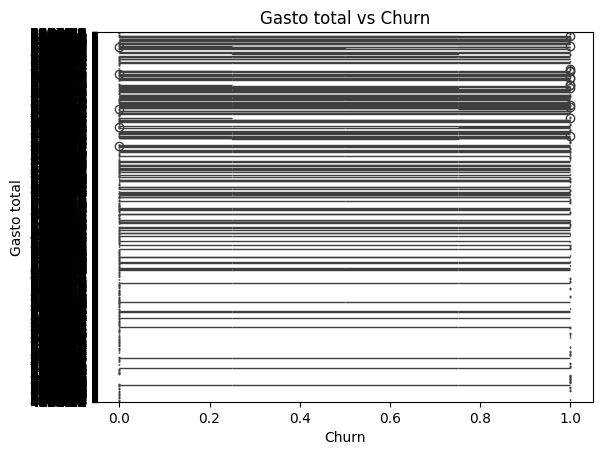

In [150]:
sns.boxplot(x='Churn', y='Charges.Total', data=df_final)

plt.title('Gasto total vs Churn')
plt.xlabel('Churn')
plt.ylabel('Gasto total')

plt.show()

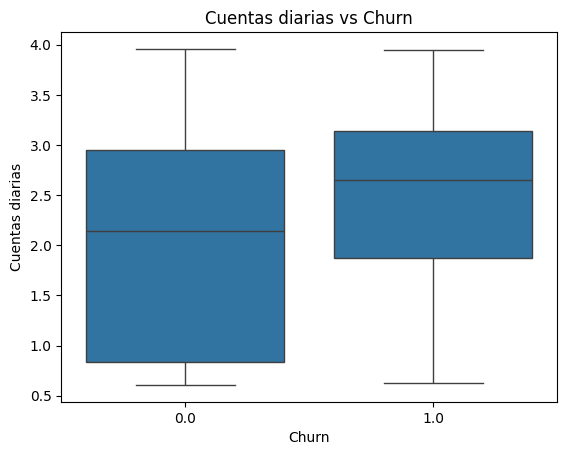

In [151]:
sns.boxplot(x='Churn', y='Cuentas_Diarias', data=df_final)

plt.title('Cuentas diarias vs Churn')
plt.xlabel('Churn')
plt.ylabel('Cuentas diarias')

plt.show()

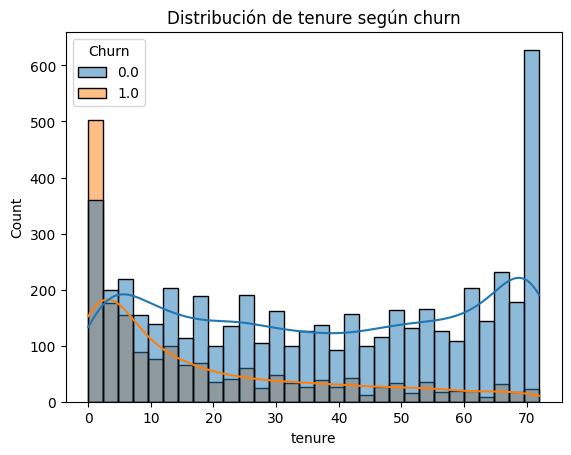

In [192]:
sns.histplot(data=df_final, x='tenure', hue='Churn', bins=30, kde=True)

plt.title('Distribución de tenure según churn')

plt.show()

#📄Informe final

# Análisis de evasión de clientes (Churn) en Telecom X

La evasión de clientes, conocida como "churn", representa uno de los principales desafíos para las empresas de telecomunicaciones, ya que implica la pérdida de clientes y, por lo tanto, de ingresos.

El objetivo de este proyecto es analizar los datos de los clientes de Telecom X para identificar patrones relacionados con la cancelación del servicio. A través de técnicas de análisis de datos y visualización, se busca comprender qué factores influyen en la evasión de clientes y generar información útil que permita a la empresa tomar decisiones estratégicas para mejorar la retención de usuarios.

## Limpieza y tratamiento de los datos

Los datos utilizados en este análisis fueron obtenidos desde una API en formato JSON. Inicialmente, se cargaron en Python utilizando la biblioteca pandas y posteriormente se transformaron en un DataFrame para facilitar su manipulación.

Durante esta etapa se realizaron varios procesos de limpieza y preparación de los datos, entre ellos:

- Desanidación de las estructuras del archivo JSON para separar la información contenida en las columnas customer, phone, internet y account.
- Revisión de valores faltantes y duplicados dentro del dataset.
- Corrección de inconsistencias en los datos, especialmente en la variable Churn.
- Conversión de algunas variables categóricas en formatos más adecuados para el análisis.
- Creación de la variable **Cuentas_Diarias**, calculada a partir de los cargos mensuales para obtener una perspectiva más detallada del gasto de los clientes.

Estos procesos permitieron preparar un conjunto de datos limpio y estructurado para realizar el análisis exploratorio.

## Análisis exploratorio de datos

Una vez preparados los datos, se realizó un análisis exploratorio con el objetivo de identificar patrones y relaciones entre las variables y la evasión de clientes.

Primero se analizó la distribución de la variable **Churn**, lo que permitió observar la proporción de clientes que permanecieron en la empresa frente a aquellos que cancelaron el servicio.

Posteriormente, se analizaron diferentes variables categóricas como el tipo de contrato, el método de pago y el tipo de servicio de internet, utilizando gráficos de barras para identificar posibles diferencias entre los clientes que cancelaron y los que permanecieron.

Finalmente, se analizaron variables numéricas como el tiempo de permanencia del cliente (tenure), los cargos mensuales y el gasto total acumulado. A través de gráficos como boxplots e histogramas se comparó el comportamiento de estas variables entre los clientes que cancelaron y los que no.

## Conclusiones e insights

A partir del análisis realizado se identificaron varios patrones importantes relacionados con la evasión de clientes.

Uno de los hallazgos más relevantes es que los clientes con contratos mensuales (month-to-month) presentan una mayor tasa de cancelación en comparación con aquellos que tienen contratos de mayor duración.

También se observó que ciertos métodos de pago, como el electronic check, presentan una mayor proporción de churn, lo que podría estar relacionado con perfiles de clientes menos comprometidos con el servicio.

En cuanto a las variables numéricas, se encontró que los clientes que cancelan el servicio suelen tener un menor tiempo de permanencia en la empresa, lo que sugiere que los primeros meses de servicio son críticos para la retención.

Además, los cargos mensuales más altos parecen estar asociados con una mayor probabilidad de evasión, lo que indica que el costo del servicio puede influir en la decisión de los clientes de cancelar.

## Recomendaciones

Con base en los resultados obtenidos, se pueden proponer algunas acciones estratégicas para reducir la evasión de clientes:

- Implementar estrategias de fidelización para clientes con contratos mensuales, incentivando la migración hacia contratos de mayor duración.
- Analizar y mejorar la experiencia de los clientes que utilizan métodos de pago asociados con mayores tasas de churn.
- Desarrollar programas de retención durante los primeros meses de servicio, ya que este periodo parece ser crítico para la permanencia del cliente.
- Revisar la estructura de precios y beneficios del servicio, especialmente para clientes con cargos mensuales elevados.

Estas acciones podrían ayudar a mejorar la satisfacción de los clientes y reducir la tasa de cancelación en el futuro.